In [1]:
"""
Deep Ensemble Base Model — Q-Model Feature Importance ONLY (LIGHTWEIGHT)

이 스크립트는 prob_threshold sweep(16 threshold x 3 model x 5-fold CV)을
완전히 생략합니다. Feature importance는 sweep과 독립적인 계산이라
ensemble inference + Q-feature 준비만 끝나면 바로 뽑을 수 있습니다.

✅ SHAP "tuple index out of range" 버그 수정
   원인: QModelMLP.forward()가 .squeeze(-1)로 1D 텐서 (N,)를 반환함.
        shap.DeepExplainer 내부(PyTorchDeep)가 모델이 단일/다중 출력인지
        판단하려고 outputs.shape[1]에 접근하는데, 1D 텐서는 shape가
        길이 1짜리 튜플이라 shape[1] 요청 시 IndexError가 발생함.
   해결: SHAP에 넘길 때만 squeeze 없이 (N, 1) shape를 유지하는
        SHAPWrapper로 모델을 감싸서 사용 + check_additivity=False
"""

import sys
sys.path.insert(0, "/fs/dss/home/gaad2403/MDS-ED/src")

import torch
from torch import nn
import numpy as np
import pandas as pd
import dataclasses
from dataclasses import dataclass, field
from typing import List
from torch.utils.data import DataLoader, TensorDataset, Dataset
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier
from collections.abc import Iterable
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore')

from clinical_ts.template_modules import EncoderStaticBase, EncoderStaticBaseConfig
from clinical_ts.ts.basic_conv1d_modules.basic_conv1d import bn_drop_lin



# XGBoost

In [4]:
BASE_DIR    = "/user/gaad2403/MDS-ED/key/Final/XGboost"
RESULTS_DIR = os.path.join(BASE_DIR, "results")
CSV_DIR     = os.path.join(RESULTS_DIR, "csv")
PNG_DIR     = os.path.join(RESULTS_DIR, "png")
DATA_PATH   = r'C:\Users\Taki Djebbar\Documents\Data Science S1\Medical Data Analysis with Deep Learning\Other\mds_ed.csv'


In [32]:
"""
XGBoost Base Model + prob_threshold sweep for Q-model pipeline (FINAL - SHAP v3).

Base model: XGBoost (tabular, same features as paper)
✅ Q-Model: Base features (tabular + masks) + prob_icu24h
✅ Feature Importance: 0.05 threshold + SHAP for MLP
✅ 모든 Feature 사용 (466 base + 466 mask + 1 prob = 933개)
"""

import sys
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, brier_score_loss
from xgboost import XGBClassifier
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# Paths
# ============================================================
BASE_DIR    = "/user/gaad2403/MDS-ED/key/Final/XGboost"
RESULTS_DIR = os.path.join(BASE_DIR, "results")
CSV_DIR     = os.path.join(RESULTS_DIR, "csv")
PNG_DIR     = os.path.join(RESULTS_DIR, "png")
DATA_PATH   = r'C:\Users\Taki Djebbar\Documents\Data Science S1\Medical Data Analysis with Deep Learning\Other\mds_ed.csv'

os.makedirs(CSV_DIR, exist_ok=True)
os.makedirs(PNG_DIR, exist_ok=True)

PROB_THRESHOLDS = np.round(np.arange(0.05, 0.21, 0.01), 2)
Q_THRESHOLDS    = np.round(np.arange(0.00, 1.01, 0.01), 2)
ICU24H_IDX      = 1
N_FOLDS         = 5
RANDOM_STATE    = 42
DEVICE          = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

MLP_HIDDEN     = [64, 32]
MLP_EPOCHS     = 50
MLP_LR         = 1e-3
MLP_BATCH_SIZE = 64
MLP_DROPOUT    = 0.3

XGB_BASE_PARAMS = dict(random_state=RANDOM_STATE, n_jobs=4, eval_metric='logloss')

print(f"prob_threshold sweep: {PROB_THRESHOLDS}")
print(f"Device: {DEVICE}")

# ============================================================
# 1. Load & preprocess data (same as paper)
# ============================================================
print("\nLoading data...")
df = pd.read_csv(DATA_PATH, low_memory=False)
print(f"shape: {df.shape}")

demographics_columns = [c for c in df.columns if 'demographics_' in c]
biometrics_columns   = [c for c in df.columns if 'biometrics_' in c]
vitals_columns       = [c for c in df.columns if 'vitals_' in c]
labvalues_columns    = [c for c in df.columns if 'labvalues_' in c]
all_features         = demographics_columns + biometrics_columns + vitals_columns + labvalues_columns

selected_folds = df[df['general_strat_fold'].isin(range(0, 18))]
medians        = selected_folds[all_features].median()

mask_columns = []
for col in all_features:
    mask_col = col + '_m'
    df[mask_col] = df[col].isna().astype(float)
    mask_columns.append(mask_col)

df[all_features]       = df[all_features].fillna(medians)
all_features_with_mask = all_features + mask_columns
print(f"Features: {len(all_features)} + {len(mask_columns)} masks = {len(all_features_with_mask)}")

target_columns = [
    'deterioration_mortality_1d',
    'deterioration_icu_24h',
    'deterioration_cardiac_arrest',
    'deterioration_vasopressors'
]

# ============================================================
# 2. Train/Val/Test split
# ============================================================
train_df = df[df['general_strat_fold'].isin(range(0, 18))].reset_index(drop=True)
val_df   = df[df['general_strat_fold'] == 18].reset_index(drop=True)
test_df  = df[df['general_strat_fold'] == 19].reset_index(drop=True)

val_df  = val_df[val_df['general_ecg_no_within_stay'] == 0].reset_index(drop=True)
test_df = test_df[test_df['general_ecg_no_within_stay'] == 0].reset_index(drop=True)

x_train = train_df[all_features_with_mask].values
x_val   = val_df[all_features_with_mask].values
x_test  = test_df[all_features_with_mask].values

y_train = train_df[target_columns].values
y_val   = val_df[target_columns].values
y_test  = test_df[target_columns].values

print(f"Train: {x_train.shape}, Val: {x_val.shape}, Test: {x_test.shape}")

# ============================================================
# 3. Train XGBoost base model (ICU 24h target only)
# ============================================================
print("\nTraining XGBoost base model (ICU 24h)...")

i = ICU24H_IDX
y_tr_raw = y_train[:, i]; y_v_raw = y_val[:, i]; y_te_raw = y_test[:, i]

mask_tr = y_tr_raw != -999
mask_v  = y_v_raw  != -999
mask_te = y_te_raw != -999

y_tr = y_tr_raw[mask_tr].astype(int)
y_v  = y_v_raw[mask_v].astype(int)
y_te = y_te_raw[mask_te].astype(int)

x_tr = x_train[mask_tr]
x_v  = x_val[mask_v]
x_te = x_test[mask_te]

val_valid_idx  = np.where(mask_v)[0]
test_valid_idx = np.where(mask_te)[0]

base_model = XGBClassifier(**XGB_BASE_PARAMS)
base_model.fit(x_tr, y_tr, eval_set=[(x_v, y_v)], verbose=False)

val_prob_icu_xgb  = base_model.predict_proba(x_v)[:, 1]
test_prob_icu_xgb = base_model.predict_proba(x_te)[:, 1]
val_true_icu_xgb  = y_v
test_true_icu_xbg = y_te

auroc_val  = roc_auc_score(y_v,  val_prob_icu_xgb)
auroc_test = roc_auc_score(y_te, test_prob_icu_xgb)
print(f"  Val  AUROC: {auroc_val:.4f}")
print(f"  Test AUROC: {auroc_test:.4f}")
print(f"  Val  samples: {len(val_prob_icu_xgb)}")
print(f"  Test samples: {len(test_prob_icu_xgb)}")

# ============================================================
# ✅ Prepare Q-Model features: Base features + Base probability
# ============================================================
print("\n" + "="*70)
print("Preparing Q-Model features (Base features + Base probability)...")
print("="*70)

X_val_features = x_v
X_test_features = x_te

print(f"\n📊 Q-Model Input Features:")
print(f"  Base tabular features: {X_val_features.shape[1]}")
print(f"  + Base probability: 1")
print(f"  = Total Q-Model features: {X_val_features.shape[1] + 1}")
print(f"\n  Val shape:  {X_val_features.shape} → Q-input: ({X_val_features.shape[0]}, {X_val_features.shape[1]+1})")
print(f"  Test shape: {X_test_features.shape} → Q-input: ({X_test_features.shape[0]}, {X_test_features.shape[1]+1})")

feature_names_qmodel = list(all_features_with_mask) + ["base_model_prob_icu24h"]
print(f"\n  Example features (first 10 + last 1):")
for i, fname in enumerate(feature_names_qmodel[:10], 1):
    print(f"    {i}. {fname}")
print("    ...")
print(f"    {len(feature_names_qmodel)}. {feature_names_qmodel[-1]}")



prob_threshold sweep: [0.05 0.06 0.07 0.08 0.09 0.1  0.11 0.12 0.13 0.14 0.15 0.16 0.17 0.18
 0.19 0.2 ]
Device: cpu

Loading data...
shape: (129057, 1936)
Features: 470 + 470 masks = 940
Train: (116433, 940), Val: (5824, 940), Test: (6080, 940)

Training XGBoost base model (ICU 24h)...
  Val  AUROC: 0.9087
  Test AUROC: 0.9116
  Val  samples: 5807
  Test samples: 6051

Preparing Q-Model features (Base features + Base probability)...

📊 Q-Model Input Features:
  Base tabular features: 940
  + Base probability: 1
  = Total Q-Model features: 941

  Val shape:  (5807, 940) → Q-input: (5807, 941)
  Test shape: (6051, 940) → Q-input: (6051, 941)

  Example features (first 10 + last 1):
    1. demographics_gender
    2. demographics_age
    3. demographics_ethnicity_asian
    4. demographics_ethnicity_black/african
    5. demographics_ethnicity_hispanic/latino
    6. demographics_ethnicity_other
    7. demographics_ethnicity_white
    8. biometrics_bmi
    9. biometrics_weight
    10. biomet

In [67]:
filtered = test_prob_icu_xgb[(test_prob_icu_xgb >= 0.6) & (test_prob_icu_xgb <= 0.8)]
filtered

array([0.67905694], dtype=float32)


XGBoost Calibration Analysis (Positive and Negative classes)
Total test samples : 6051
Positive (label=1) : 730
Negative (label=0) : 5321

Expected Calibration Error (ECE):
  Positive class (label=1) ECE : 0.0141
  Negative class (label=0) ECE : 0.0141

Brier Score:
  Positive class (label=1) : 0.0599
  Negative class (label=0) : 0.0599


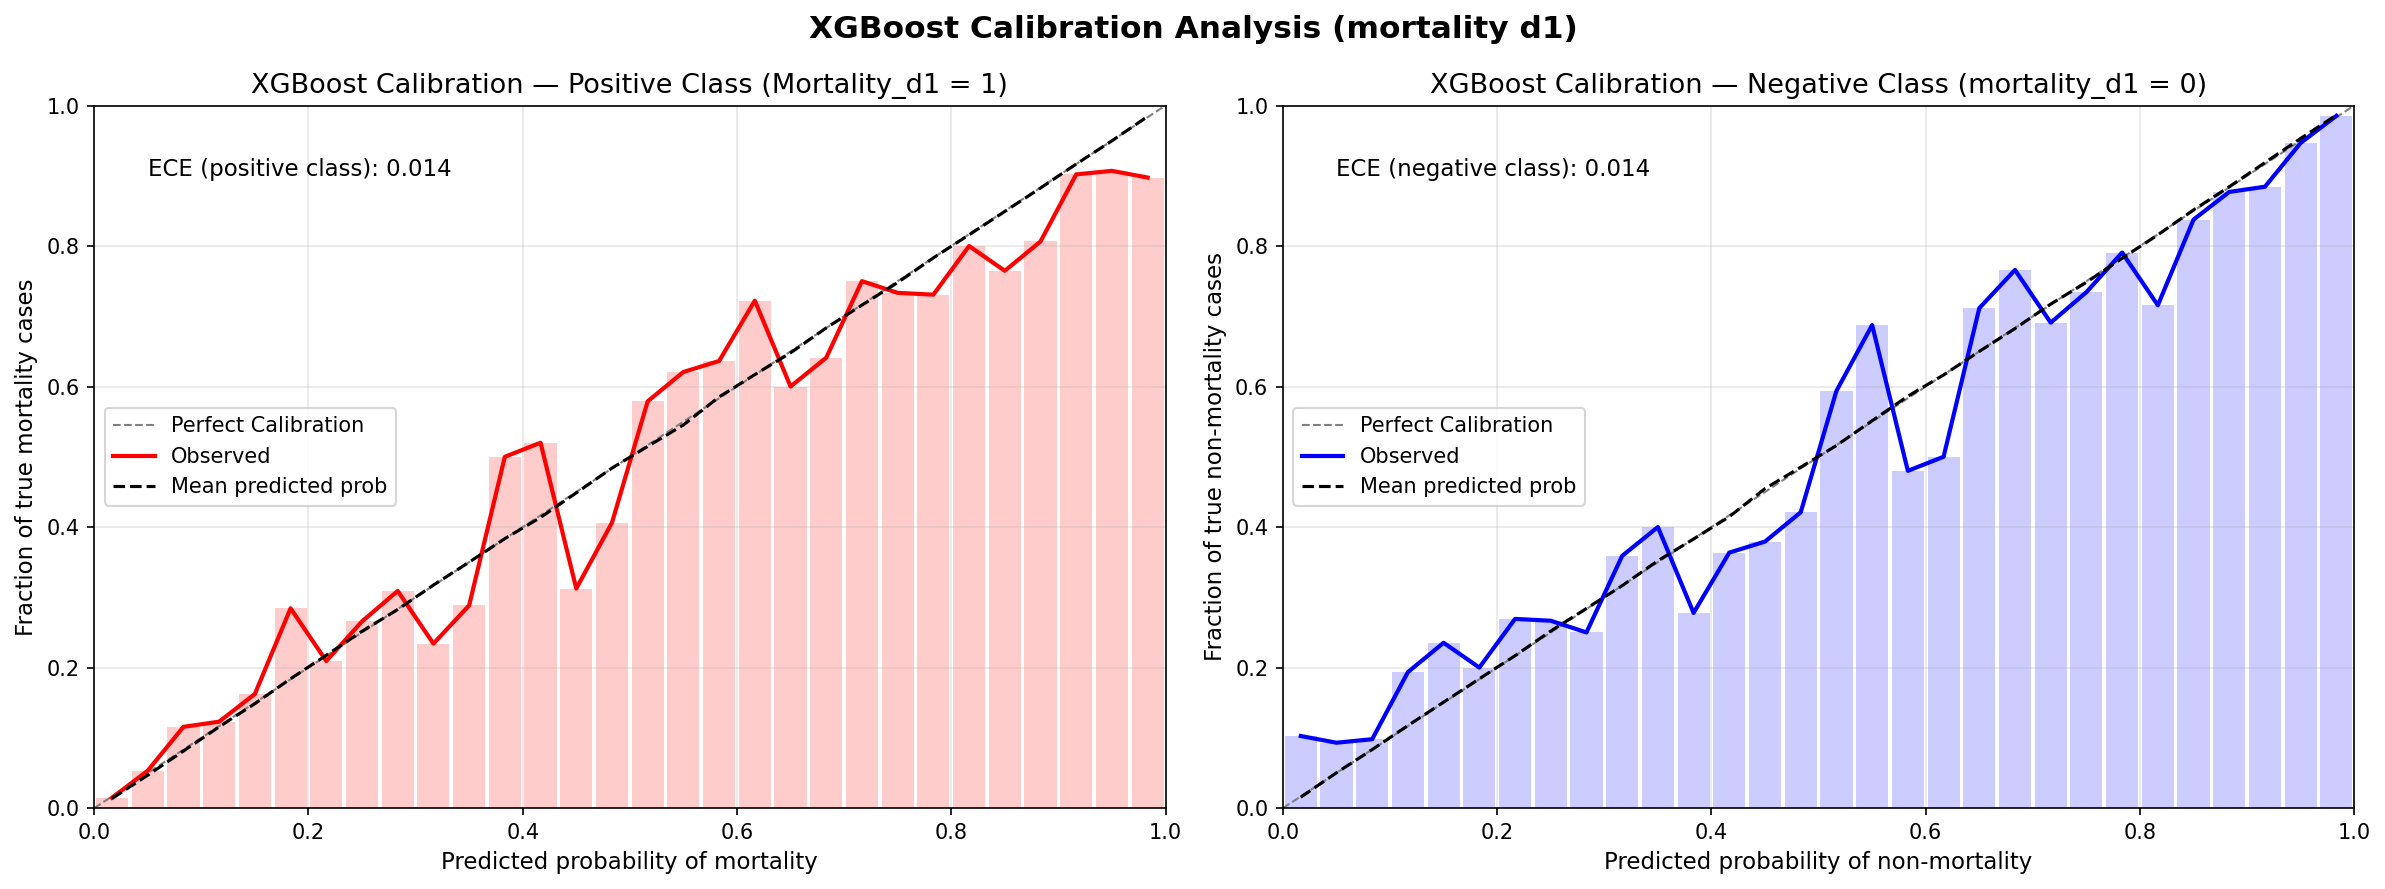

In [33]:
%matplotlib inline
import matplotlib.pyplot as plt
from sklearn.metrics import brier_score_loss
import io
from PIL import Image
from IPython.display import display

# ============================================================
# Calibration Analysis for XGBoost - both classes
# ============================================================
print("\n" + "="*70)
print("XGBoost Calibration Analysis (Positive and Negative classes)")
print("="*70)

# XGBoost data already computed from the main code
xgb_prob = test_prob_icu_xgb.copy()
xgb_true = test_true_icu_xbg.copy()

# Remove NaNs
mask_valid   = ~np.isnan(xgb_prob) & ~np.isnan(xgb_true.astype(float))
xgb_prob     = xgb_prob[mask_valid]
xgb_true     = xgb_true[mask_valid].astype(int)

print(f"Total test samples : {len(xgb_true)}")
print(f"Positive (label=1) : {xgb_true.sum()}")
print(f"Negative (label=0) : {(xgb_true == 0).sum()}")

# ============================================================
# ECE function
# ============================================================
def compute_ece_by_class(y_true, y_prob, target_class=1, n_bins=30):
    y_prob = y_prob.copy()
    y_true = y_true.copy()

    if target_class == 0:
        y_prob = 1 - y_prob
        y_true = (y_true == 0).astype(int)
    else:
        y_true = (y_true == 1).astype(int)

    bins         = np.linspace(0, 1, n_bins + 1)
    bin_frac_pos = []
    bin_conf     = []
    bin_sizes    = []
    ece          = 0.0
    n            = len(y_true)

    for i in range(n_bins):
        left, right = bins[i], bins[i + 1]
        bin_mask    = (y_prob >= left) & (y_prob <= right) if i == n_bins - 1 \
                      else (y_prob >= left) & (y_prob < right)
        size        = np.sum(bin_mask)

        if size == 0:
            bin_frac_pos.append(np.nan)
            bin_conf.append(np.nan)
            bin_sizes.append(0)
            continue

        frac_pos = np.sum(y_true[bin_mask] == 1) / size
        conf     = np.mean(y_prob[bin_mask])
        ece     += (size / n) * abs(frac_pos - conf)

        bin_frac_pos.append(frac_pos)
        bin_conf.append(conf)
        bin_sizes.append(size)

    return ece, bins, np.array(bin_frac_pos), np.array(bin_conf), np.array(bin_sizes)

# ============================================================
# Compute bins for both classes
# ============================================================
n_bins    = 30
bin_width = 1.0 / n_bins

xgb_ece_pos, xgb_bins_1, xgb_frac_1, xgb_conf_1, xgb_sizes_1 = compute_ece_by_class(
    xgb_true, xgb_prob, target_class=1, n_bins=n_bins)

xgb_ece_neg, xgb_bins_0, xgb_frac_0, xgb_conf_0, xgb_sizes_0 = compute_ece_by_class(
    xgb_true, xgb_prob, target_class=0, n_bins=n_bins)

xgb_centers_1 = (xgb_bins_1[:-1] + xgb_bins_1[1:]) / 2
xgb_centers_0 = (xgb_bins_0[:-1] + xgb_bins_0[1:]) / 2

xgb_brier_pos = brier_score_loss(xgb_true,       xgb_prob)
xgb_brier_neg = brier_score_loss(1 - xgb_true,   1 - xgb_prob)

print(f"\nExpected Calibration Error (ECE):")
print(f"  Positive class (label=1) ECE : {xgb_ece_pos:.4f}")
print(f"  Negative class (label=0) ECE : {xgb_ece_neg:.4f}")
print(f"\nBrier Score:")
print(f"  Positive class (label=1) : {xgb_brier_pos:.4f}")
print(f"  Negative class (label=0) : {xgb_brier_neg:.4f}")

# ============================================================
# Plot
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ------------------------------------------------------------
# Positive class (label=1)
# ------------------------------------------------------------
axes[0].plot([0, 1], [0, 1], '--', color='gray', linewidth=1,
             label='Perfect Calibration')
axes[0].plot(xgb_centers_1, xgb_frac_1, color='red', linewidth=2,
             label='Observed')
axes[0].plot(xgb_centers_1, xgb_conf_1, color='black', linestyle='--',
             label='Mean predicted prob')
axes[0].bar(xgb_centers_1, xgb_frac_1, width=bin_width * 0.9,
            alpha=0.2, color='red')
axes[0].text(0.05, 0.90, f"ECE (positive class): {xgb_ece_pos:.3f}",
             transform=axes[0].transAxes, fontsize=11)
axes[0].set_xlabel('Predicted probability of mortality', fontsize=11)
axes[0].set_ylabel('Fraction of true mortality cases', fontsize=11)
axes[0].set_title('XGBoost Calibration — Positive Class (Mortality_d1 = 1)', fontsize=13)
axes[0].legend(fontsize=10)
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1])
axes[0].grid(alpha=0.3)

# ------------------------------------------------------------
# Negative class (label=0)
# ------------------------------------------------------------
axes[1].plot([0, 1], [0, 1], '--', color='gray', linewidth=1,
             label='Perfect Calibration')
axes[1].plot(xgb_centers_0, xgb_frac_0, color='blue', linewidth=2,
             label='Observed')
axes[1].plot(xgb_centers_0, xgb_conf_0, color='black', linestyle='--',
             label='Mean predicted prob')
axes[1].bar(xgb_centers_0, xgb_frac_0, width=bin_width * 0.9,
            alpha=0.2, color='blue')
axes[1].text(0.05, 0.90, f"ECE (negative class): {xgb_ece_neg:.3f}",
             transform=axes[1].transAxes, fontsize=11)
axes[1].set_xlabel('Predicted probability of non-mortality', fontsize=11)
axes[1].set_ylabel('Fraction of true non-mortality cases', fontsize=11)
axes[1].set_title('XGBoost Calibration — Negative Class (mortality_d1 = 0)', fontsize=13)
axes[1].legend(fontsize=10)
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1])
axes[1].grid(alpha=0.3)

plt.suptitle('XGBoost Calibration Analysis (mortality d1)',
             fontsize=15, fontweight='bold')
plt.tight_layout()

# Force inline display
buf = io.BytesIO()
plt.savefig(buf, format='png', dpi=150, bbox_inches='tight')
buf.seek(0)
display(Image.open(buf))
plt.savefig(os.path.join(PNG_DIR, "calibration_xgboost.png"),
            dpi=150, bbox_inches='tight')
plt.close()

In [36]:
# ============================================================
# Calibration Methods (Platt + Isotonic)
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.isotonic import IsotonicRegression

# ------------------------------------------------------------
# Validation predictions (must already exist)
# ------------------------------------------------------------
# val_prob_icu_xgb
# val_true_icu_xgb

# -----------------------------
# Original probabilities
# -----------------------------
prob_xgb = xgb_prob.copy()

# -----------------------------
# Platt Scaling
# -----------------------------
platt = LogisticRegression(max_iter=1000)

platt.fit(
    val_prob_icu_xgb.reshape(-1, 1),
    val_true_icu_xgb.astype(int)
)

prob_platt = platt.predict_proba(
    xgb_prob.reshape(-1, 1)
)[:, 1]

# -----------------------------
# Isotonic Regression
# -----------------------------
iso = IsotonicRegression(out_of_bounds="clip")

iso.fit(
    val_prob_icu_xgb,
    val_true_icu_xgb.astype(int)
)

prob_iso = iso.predict(xgb_prob)

# ============================================================
# Calibration Matrix
# ============================================================

calibration_matrix = np.column_stack([
    xgb_true,
    prob_xgb,
    prob_platt,
    prob_iso
])

headers = [
    "True_Label",
    "Original_Probability",
    "Platt_Scaling",
    "Isotonic_Regression"
]

print("\nCalibration Matrix Shape:", calibration_matrix.shape)

# Optional: DataFrame for easier viewing/saving
import pandas as pd

calibration_XGB = pd.DataFrame(
    calibration_matrix,
    columns=headers
)

print(calibration_XGB.head())

# Optional
# calibration_df.to_csv("xgboost_calibration_matrix.csv", index=False)


Calibration Matrix Shape: (6051, 4)
   True_Label  Original_Probability  Platt_Scaling  Isotonic_Regression
0         0.0              0.028227       0.042478             0.036649
1         1.0              0.870264       0.851617             0.791045
2         0.0              0.002639       0.036858             0.000000
3         1.0              0.482145       0.378947             0.562500
4         1.0              0.023707       0.041429             0.036649


# Deep Ensembles

In [5]:
"""
prob_threshold sweep for Deep Ensemble Q-model pipeline (FINAL - SHAP v3).

✅ Q-Model: Base features (cont+cat) + Ensemble stats (prob, var, ent, spread)
✅ Feature Importance: 0.05 threshold + SHAP for MLP
✅ 모든 Feature 사용 (cont 464 + cat 2 + ensemble 4 = 470개)
"""

import sys
sys.path.insert(0, "/fs/dss/home/gaad2403/MDS-ED/src")

import torch
from torch import nn
import numpy as np
import pandas as pd
import dataclasses
from dataclasses import dataclass, field
from typing import List
from torch.utils.data import DataLoader, TensorDataset, Dataset
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, brier_score_loss
from xgboost import XGBClassifier
from collections.abc import Iterable
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore')

from clinical_ts.template_modules import EncoderStaticBase, EncoderStaticBaseConfig
from clinical_ts.ts.basic_conv1d_modules.basic_conv1d import bn_drop_lin

# ============================================================
# Paths
# ============================================================
BASE_DIR    = r"C:\user\gaad2403\MDS-ED\key\Final\DeepEnsemble"
RESULTS_DIR = os.path.join(BASE_DIR, "results")
CSV_DIR     = os.path.join(RESULTS_DIR, "csv")
PNG_DIR     = os.path.join(RESULTS_DIR, "png")

os.makedirs(CSV_DIR, exist_ok=True)
os.makedirs(PNG_DIR, exist_ok=True)

PROB_THRESHOLDS = np.round(np.arange(0.05, 0.21, 0.01), 2)
Q_THRESHOLDS    = np.round(np.arange(0.00, 1.01, 0.01), 2)
ICU24H_IDX      = 1
BATCH_SIZE      = 32
LIN_FTRS        = [128, 128, 128]
M               = 5
EPSILON         = 1e-10
N_FOLDS         = 5
RANDOM_STATE    = 42
DEVICE          = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

MLP_HIDDEN     = [64, 32]
MLP_EPOCHS     = 50
MLP_LR         = 1e-3
MLP_BATCH_SIZE = 64
MLP_DROPOUT    = 0.3

ENSEMBLE_FEATURE_COLS = ["prob_icu24h", "variance", "entropy", "spread"]

print(f"prob_threshold sweep: {PROB_THRESHOLDS}")
print(f"Ensemble features: {ENSEMBLE_FEATURE_COLS}")
print(f"Device: {DEVICE}")

# ============================================================
# Model definitions (unchanged)
# ============================================================
class BasicEncoderStatic(EncoderStaticBase):
    def __init__(self, hparams_encoder_static, hparams_input_shape, target_dim=None):
        super().__init__(hparams_encoder_static, hparams_input_shape, target_dim)
        self.input_channels_cat  = hparams_input_shape.static_dim_cat
        self.input_channels_cont = hparams_input_shape.static_dim
        assert(len(hparams_encoder_static.embedding_dims) == hparams_input_shape.static_dim_cat
               and len(hparams_encoder_static.vocab_sizes) == hparams_input_shape.static_dim_cat)
        self.embeddings = nn.ModuleList()
        for v, e in zip(hparams_encoder_static.vocab_sizes, hparams_encoder_static.embedding_dims):
            self.embeddings.append(nn.Embedding(v, e))
        self.input_dim = int(np.sum(hparams_encoder_static.embedding_dims) + hparams_input_shape.static_dim)

    def embed(self, **kwargs):
        static     = kwargs.get("static", None)
        static_cat = kwargs.get("static_cat", None)
        res = []
        if static_cat is not None:
            for i, e in enumerate(self.embeddings):
                res.append(e(static_cat[:, i].long()))
            res = torch.cat([torch.cat(res, dim=1), static], dim=1) if static is not None else torch.cat(res, dim=1)
        else:
            res = static
        return res

    def forward(self, **kwargs): raise NotImplementedError
    def get_output_shape(self):  raise NotImplementedError


class BasicEncoderStaticMLP(BasicEncoderStatic):
    def __init__(self, hparams_encoder_static, hparams_input_shape, target_dim=None):
        super().__init__(hparams_encoder_static, hparams_input_shape, target_dim)
        lin_ftrs = [self.input_dim] + list(hparams_encoder_static.lin_ftrs)
        if target_dim is not None and lin_ftrs[-1] != target_dim:
            lin_ftrs.append(target_dim)
        ps = ([hparams_encoder_static.dropout]
              if not isinstance(hparams_encoder_static.dropout, Iterable)
              else hparams_encoder_static.dropout)
        if len(ps) == 1:
            ps = [ps[0] / 2] * (len(lin_ftrs) - 2) + ps
        actns  = [nn.ReLU(inplace=True)] * (len(lin_ftrs) - 2) + [None]
        layers = []
        for ni, no, p, actn in zip(lin_ftrs[:-1], lin_ftrs[1:], ps, actns):
            layers += bn_drop_lin(ni, no, hparams_encoder_static.batch_norm, p, actn, layer_norm=False)
        self.layers = nn.Sequential(*layers)
        self.output_shape = dataclasses.replace(hparams_input_shape)
        self.output_shape.static_dim     = int(lin_ftrs[-1])
        self.output_shape.static_dim_cat = 0

    def forward(self, **kwargs):
        return {"static": self.layers(self.embed(**kwargs))}

    def get_output_shape(self):
        return self.output_shape


@dataclass
class BasicEncoderStaticConfig(EncoderStaticBaseConfig):
    _target_: str = "clinical_ts.tabular.base.BasicEncoderStatic"
    embedding_dims: List[int] = field(default_factory=list)
    vocab_sizes: List[int]    = field(default_factory=list)

@dataclass
class MLPConfig:
    embedding_dims: List[int] = field(default_factory=list)
    vocab_sizes: List[int]    = field(default_factory=list)
    lin_ftrs: List[int]       = field(default_factory=lambda: [128, 128, 128])
    dropout: float   = 0.5
    batch_norm: bool = True

@dataclass
class ShapeCfg:
    static_dim: int     = 0
    static_dim_cat: int = 0
    channels: int       = 0
    length: int         = 0
    sequence_last: bool = False
    channels2: int      = 0

# ============================================================
# 1. Load & preprocess data
# ============================================================
print("\nLoading data...")
df = pd.read_csv(DATA_PATH, low_memory=False)

input_cols    = [c for c in df.columns if c.split("_")[0] in ['biometrics','demographics','labvalues','vitals']]
df_train      = df[df['general_strat_fold'] < 18]
train_medians = df_train[input_cols].median().to_dict()
for c in [c for c, v in df_train[input_cols].isna().sum().items() if v > 0]:
    df.loc[df[c].isna(), c] = train_medians[c]
df = df.copy()

unique_counts = {c: len(np.unique(np.array(df[c]))) for c in input_cols}
cat_features  = [c for c, v in unique_counts.items()
                 if v < 10 and not c.endswith("nan") and not c.startswith("labvalues")]
cont_features = [c for c in input_cols if c not in cat_features]

df["vitals_acuity"] = df["vitals_acuity"].apply(lambda x: int(x) - 1)
lbl_eth = ['demographics_ethnicity_asian','demographics_ethnicity_black/african',
           'demographics_ethnicity_hispanic/latino','demographics_ethnicity_other',
           'demographics_ethnicity_white']
df["demographics_ethnicity"] = df.apply(lambda r: np.where([r[c] for c in lbl_eth])[0][0], axis=1)
df.drop(lbl_eth, axis=1, inplace=True)

input_cols    = [c for c in df.columns if c.split("_")[0] in ['biometrics','demographics','labvalues','vitals']]
cat_features  = [c for c in input_cols if c in cat_features]
cont_features = [c for c in input_cols if c not in cat_features]

lbl_itos = ["mortality_1d", "icu_24h", "cardiac_arrest", "vasopressors"]
for c in lbl_itos:
    df["deterioration_" + c] = df["deterioration_" + c].replace(-999., np.nan)

val_df  = df[df['general_strat_fold'] == 18].reset_index(drop=True)
test_df = df[df['general_strat_fold'] == 19].reset_index(drop=True)
val_df  = val_df[val_df['general_ecg_no_within_stay'] == 0].reset_index(drop=True)
test_df = test_df[test_df['general_ecg_no_within_stay'] == 0].reset_index(drop=True)
print(f"Val: {len(val_df)}, Test: {len(test_df)}")

# ============================================================
# 2. Dataset & DataLoader
# ============================================================
class TabularDataset(Dataset):
    def __init__(self, df, cont_f, cat_f, lbl_cols):
        self.cont   = torch.tensor(df[cont_f].values, dtype=torch.float32)
        self.cat    = torch.tensor(df[cat_f].values,  dtype=torch.long)
        self.labels = torch.tensor(df[["deterioration_"+c for c in lbl_cols]].values, dtype=torch.float32)
    def __len__(self): return len(self.cont)
    def __getitem__(self, i): return self.cont[i], self.cat[i], self.labels[i]

val_loader  = DataLoader(TabularDataset(val_df,  cont_features, cat_features, lbl_itos),
                         batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(TabularDataset(test_df, cont_features, cat_features, lbl_itos),
                         batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# ============================================================
# 3. Load ensemble members & inference
# ============================================================
shape   = ShapeCfg(static_dim=len(cont_features), static_dim_cat=len(cat_features))
mlp_cfg = MLPConfig(
    embedding_dims=[unique_counts[c] for c in cat_features],
    vocab_sizes=[unique_counts[c] for c in cat_features],
    lin_ftrs=LIN_FTRS
)

print(f"\nLoading {M} ensemble members...")
ensemble_models = []
for m in range(M):
    pt_path = os.path.join(BASE_DIR, f"ensemble_model_{m}.pt")
    model   = BasicEncoderStaticMLP(mlp_cfg, shape, target_dim=len(lbl_itos)).to(DEVICE)
    model.load_state_dict(torch.load(pt_path, map_location=DEVICE, weights_only=False))
    model.eval()
    ensemble_models.append(model)
    print(f"  Loaded: {pt_path}")


def ensemble_predict(models, loader):
    all_preds_per_model = []
    for model in models:
        model.eval()
        preds = []
        with torch.no_grad():
            for cont, cat, _ in loader:
                cont, cat = cont.to(DEVICE), cat.to(DEVICE)
                probs = torch.sigmoid(model(static=cont, static_cat=cat)["static"]).cpu().numpy()
                preds.append(probs)
        all_preds_per_model.append(np.concatenate(preds, axis=0))

    all_labels = []
    for _, _, labels in loader:
        all_labels.append(labels.numpy())
    all_labels = np.concatenate(all_labels, axis=0)

    stacked   = np.stack(all_preds_per_model, axis=0)
    mean_pred = stacked.mean(axis=0)
    variance  = stacked.var(axis=0)
    spread    = stacked.max(axis=0) - stacked.min(axis=0)
    p         = mean_pred
    entropy   = -(p * np.log(p + EPSILON) + (1-p) * np.log(1-p + EPSILON))

    return mean_pred, variance, entropy, spread, all_labels


print("Running ensemble inference...")
print("  Val set...")
val_mean,  val_var,  val_ent,  val_spr,  val_labels  = ensemble_predict(ensemble_models, val_loader)
print("  Test set...")
test_mean, test_var, test_ent, test_spr, test_labels = ensemble_predict(ensemble_models, test_loader)
print("  Done.")

# Per-sample probability for ICU 24h on test set
test_prob_icu_deep_ensembles = test_mean[:, ICU24H_IDX]
print(f"\nTest set probabilities (ICU 24h) per sample:")
print(f"  Shape : {test_prob_icu_deep_ensembles.shape}")
print(f"  Min   : {test_prob_icu_deep_ensembles.min():.4f}")
print(f"  Max   : {test_prob_icu_deep_ensembles.max():.4f}")
print(f"  Mean  : {test_prob_icu_deep_ensembles.mean():.4f}")

prob_threshold sweep: [0.05 0.06 0.07 0.08 0.09 0.1  0.11 0.12 0.13 0.14 0.15 0.16 0.17 0.18
 0.19 0.2 ]
Ensemble features: ['prob_icu24h', 'variance', 'entropy', 'spread']
Device: cpu

Loading data...
Val: 5824, Test: 6080

Loading 5 ensemble members...
  Loaded: C:\user\gaad2403\MDS-ED\key\Final\DeepEnsemble\ensemble_model_0.pt
  Loaded: C:\user\gaad2403\MDS-ED\key\Final\DeepEnsemble\ensemble_model_1.pt
  Loaded: C:\user\gaad2403\MDS-ED\key\Final\DeepEnsemble\ensemble_model_2.pt
  Loaded: C:\user\gaad2403\MDS-ED\key\Final\DeepEnsemble\ensemble_model_3.pt
  Loaded: C:\user\gaad2403\MDS-ED\key\Final\DeepEnsemble\ensemble_model_4.pt
Running ensemble inference...
  Val set...
  Test set...
  Done.

Test set probabilities (ICU 24h) per sample:
  Shape : (6080,)
  Min   : 0.0021
  Max   : 1.0000
  Mean  : 0.1167


Threshold=0.13: TP=575, FP=761, FN=155, TN=4560


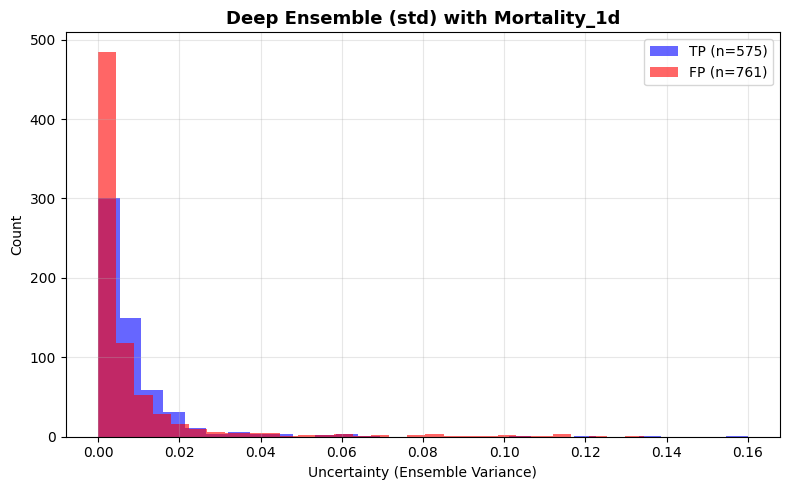

In [8]:
%matplotlib inline
# ============================================================
# 4. Uncertainty distribution: TP vs FP (Deep Ensemble, ICU 24h)
# ============================================================
from sklearn.metrics import confusion_matrix

# Pick an operating threshold (e.g. one of your PROB_THRESHOLDS,
# or whichever value hits your target sensitivity)
THRESHOLD = 0.13
ICU24H_IDX=1
y_true_icu = test_labels[:, ICU24H_IDX]
y_prob_icu = test_mean[:, ICU24H_IDX]
y_var_icu  = test_var[:, ICU24H_IDX]   # ensemble variance = uncertainty proxy

mask = ~np.isnan(y_true_icu)
y_true_icu = y_true_icu[mask]
y_prob_icu = y_prob_icu[mask]
y_var_icu  = y_var_icu[mask]

# Optional: check FP count at this threshold, like your MC Dropout section
y_class = (y_prob_icu >= THRESHOLD).astype(int)
tn, fp, fn, tp = confusion_matrix(y_true_icu, y_class).ravel()
print(f"Threshold={THRESHOLD}: TP={tp}, FP={fp}, FN={fn}, TN={tn}")

predicted_pos = y_prob_icu >= THRESHOLD
tp_mask = predicted_pos & (y_true_icu == 1)
fp_mask = predicted_pos & (y_true_icu == 0)

tp_uncertainty = y_var_icu[tp_mask]
fp_uncertainty = y_var_icu[fp_mask]

plt.figure(figsize=(8, 5))
plt.hist(tp_uncertainty, bins=30, alpha=0.6, color="blue", label=f"TP (n={tp_mask.sum()})")
plt.hist(fp_uncertainty, bins=30, alpha=0.6, color="red",  label=f"FP (n={fp_mask.sum()})")
plt.title("Deep Ensemble (std) with Mortality_1d",
          fontsize=13, fontweight="bold")
plt.xlabel("Uncertainty (Ensemble Variance)")
plt.ylabel("Count")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PNG_DIR, "uncertainty_tp_fp_icu_24h_deepensemble.png"),
            dpi=150, bbox_inches="tight")
plt.show()


Calibration Analysis (Positive and Negative classes)
Total test samples : 6051
Positive (label=1) : 730
Negative (label=0) : 5321

Expected Calibration Error (ECE):
  Positive class (label=1) ECE : 0.0235
  Negative class (label=0) ECE : 0.0238

Brier Score:
  Positive class (label=1) : 0.0709
  Negative class (label=0) : 0.0709


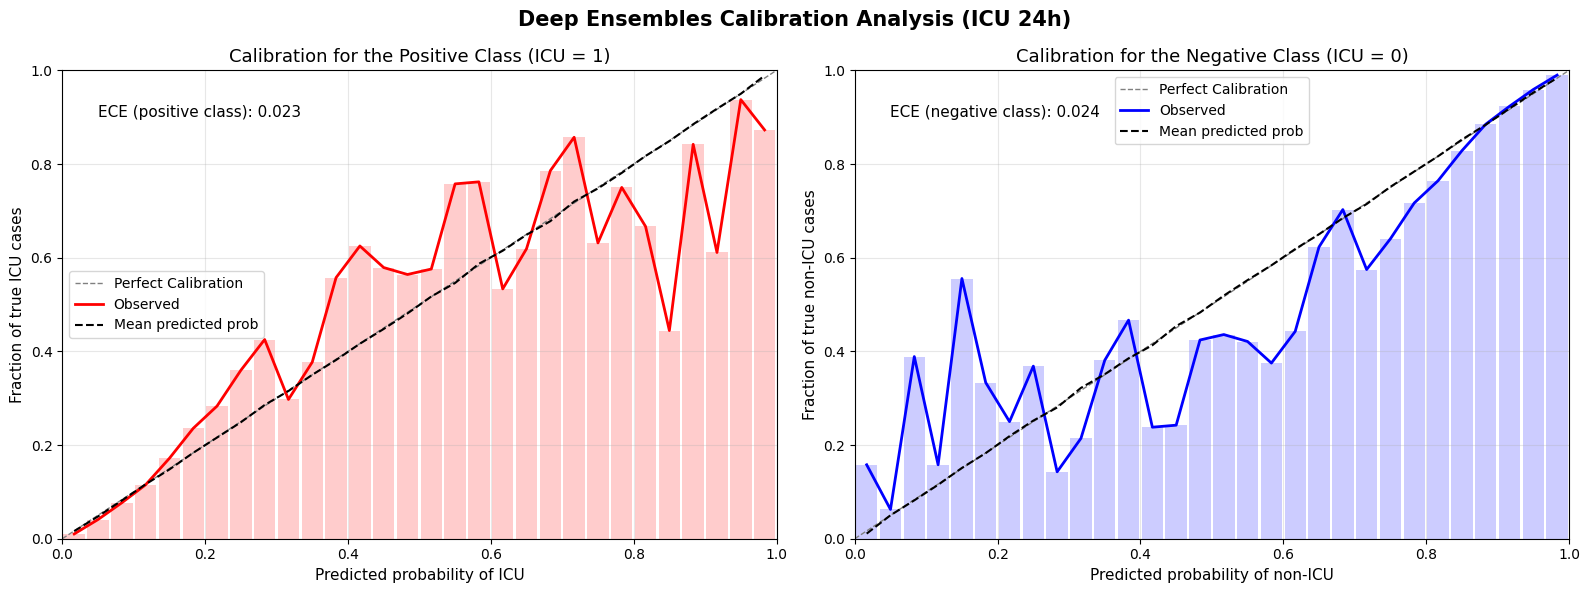

In [14]:
%matplotlib inline
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

# ============================================================
# Calibration Analysis for both classes
# ============================================================
print("\n" + "="*70)
print("Calibration Analysis (Positive and Negative classes)")
print("="*70)

# Apply mask to get only valid (non-NaN) samples
test_mask     = ~np.isnan(test_labels[:, ICU24H_IDX])
test_prob_icu_deep_ensembles = test_mean[test_mask, ICU24H_IDX]
test_true_icu_deep_ensembles = test_labels[test_mask, ICU24H_IDX].astype(int)

print(f"Total test samples : {len(test_true_icu_deep_ensembles)}")
print(f"Positive (label=1) : {test_true_icu_deep_ensembles.sum()}")
print(f"Negative (label=0) : {(test_true_icu_deep_ensembles == 0).sum()}")

# ECE function
def compute_ece(true_labels, pred_probs, n_bins=30):
    bins  = np.linspace(0.0, 1.0, n_bins + 1)
    ece   = 0.0
    total = len(pred_probs)
    for i in range(n_bins):
        mask      = (pred_probs >= bins[i]) & (pred_probs < bins[i+1])
        bin_count = mask.sum()
        if bin_count == 0:
            continue
        ece += (bin_count / total) * abs(true_labels[mask].mean() - pred_probs[mask].mean())
    return ece

# ============================================================
# Compute bins manually for both classes
# ============================================================
n_bins    = 30
bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
bin_width = bin_edges[1] - bin_edges[0]
centers   = (bin_edges[:-1] + bin_edges[1:]) / 2

# --- Positive class ---
frac_pos_DE = np.full(n_bins, np.nan)
conf_pos     = np.full(n_bins, np.nan)
for i in range(n_bins):
    mask = (test_prob_icu_deep_ensembles >= bin_edges[i]) & (test_prob_icu_deep_ensembles < bin_edges[i+1])
    if mask.sum() > 0:
        frac_pos_DE[i] = test_true_icu_deep_ensembles[mask].mean()
        conf_pos[i]     = test_prob_icu_deep_ensembles[mask].mean()

# --- Negative class ---
neg_probs    = 1 - test_prob_icu_deep_ensembles
neg_true     = 1 - test_true_icu_deep_ensembles
frac_neg_DE = np.full(n_bins, np.nan)
conf_neg     = np.full(n_bins, np.nan)
for i in range(n_bins):
    mask = (neg_probs >= bin_edges[i]) & (neg_probs < bin_edges[i+1])
    if mask.sum() > 0:
        frac_neg_DE[i] = neg_true[mask].mean()
        conf_neg[i]     = neg_probs[mask].mean()

ece_pos_DE = compute_ece(test_true_icu_deep_ensembles, test_prob_icu_deep_ensembles,   n_bins=30)
ece_neg_DE = compute_ece(neg_true,      neg_probs,        n_bins=30)

brier_pos = brier_score_loss(test_true_icu_deep_ensembles, test_prob_icu_deep_ensembles)
brier_neg = brier_score_loss(neg_true,      neg_probs)

print(f"\nExpected Calibration Error (ECE):")
print(f"  Positive class (label=1) ECE : {ece_pos_DE:.4f}")
print(f"  Negative class (label=0) ECE : {ece_neg_DE:.4f}")
print(f"\nBrier Score:")
print(f"  Positive class (label=1) : {brier_pos:.4f}")
print(f"  Negative class (label=0) : {brier_neg:.4f}")

# ============================================================
# Plot
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ------------------------------------------------------------
# Positive class
# ------------------------------------------------------------
axes[0].plot([0, 1], [0, 1], '--', color='gray', linewidth=1,
             label='Perfect Calibration')
axes[0].plot(centers, frac_pos_DE, color='red', linewidth=2,
             label='Observed')
axes[0].plot(centers, conf_pos, color='black', linestyle='--',
             label='Mean predicted prob')
axes[0].bar(centers, frac_pos_DE, width=bin_width * 0.9,
            alpha=0.2, color='red')
axes[0].text(0.05, 0.90, f"ECE (positive class): {ece_pos_DE:.3f}",
             transform=axes[0].transAxes, fontsize=11)
axes[0].set_xlabel('Predicted probability of ICU', fontsize=11)
axes[0].set_ylabel('Fraction of true ICU cases', fontsize=11)
axes[0].set_title('Calibration for the Positive Class (ICU = 1)', fontsize=13)
axes[0].legend(fontsize=10)
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1])
axes[0].grid(alpha=0.3)

# ------------------------------------------------------------
# Negative class
# ------------------------------------------------------------
axes[1].plot([0, 1], [0, 1], '--', color='gray', linewidth=1,
             label='Perfect Calibration')
axes[1].plot(centers, frac_neg_DE, color='blue', linewidth=2,
             label='Observed')
axes[1].plot(centers, conf_neg, color='black', linestyle='--',
             label='Mean predicted prob')
axes[1].bar(centers, frac_neg_DE, width=bin_width * 0.9,
            alpha=0.2, color='blue')
axes[1].text(0.05, 0.90, f"ECE (negative class): {ece_neg_DE:.3f}",
             transform=axes[1].transAxes, fontsize=11)
axes[1].set_xlabel('Predicted probability of non-ICU', fontsize=11)
axes[1].set_ylabel('Fraction of true non-ICU cases', fontsize=11)
axes[1].set_title('Calibration for the Negative Class (ICU = 0)', fontsize=13)
axes[1].legend(fontsize=10)
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1])
axes[1].grid(alpha=0.3)

plt.suptitle('Deep Ensembles Calibration Analysis (ICU 24h)',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PNG_DIR, "calibration_both_classes.png"),
            dpi=150, bbox_inches='tight')
plt.show()

Patients predicted ICU (class 1)     : 1336, ECE = 0.0892
Patients predicted non-ICU (class 0) : 4715, ECE = 0.0067


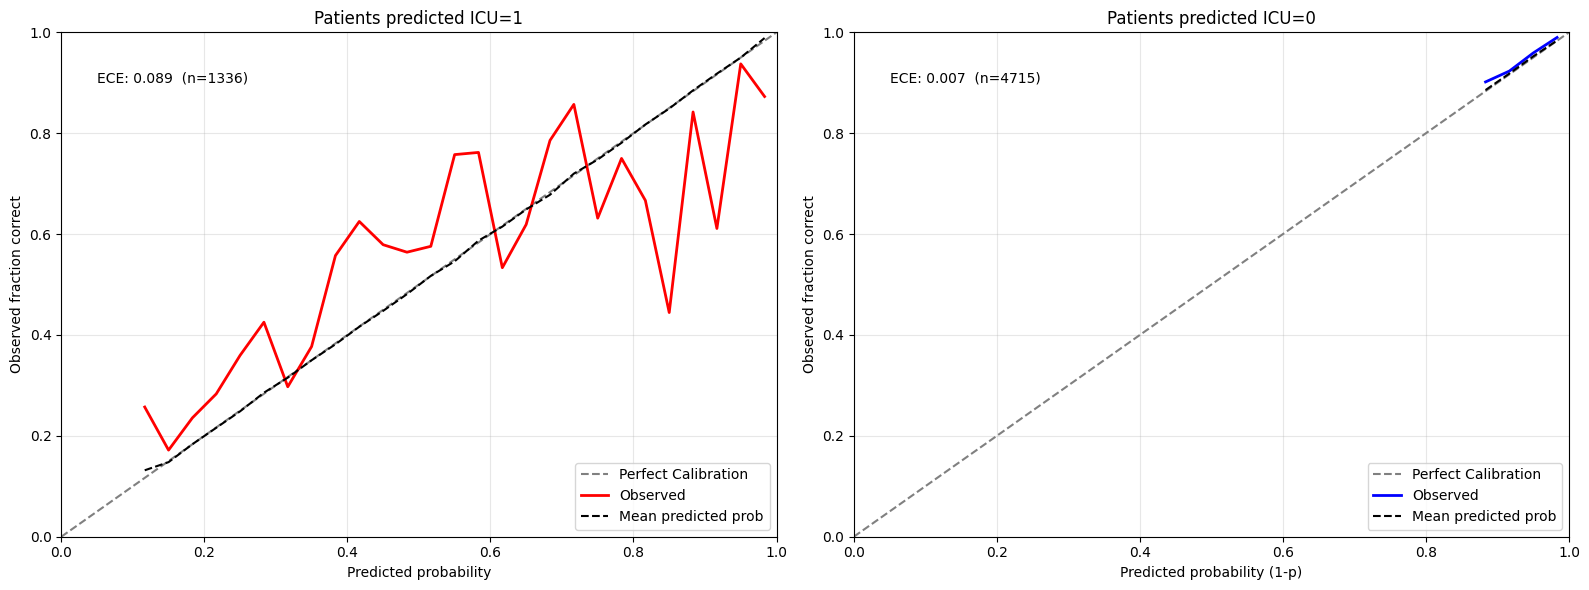

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Data
# ============================================================
test_mask = ~np.isnan(test_labels[:, ICU24H_IDX])
probs = test_mean[test_mask, ICU24H_IDX]           # P(ICU=1) per patient
true  = test_labels[test_mask, ICU24H_IDX].astype(int)

n_bins = 30
bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
bin_width = bin_edges[1] - bin_edges[0]
centers   = (bin_edges[:-1] + bin_edges[1:]) / 2

def compute_ece(y_true, y_conf, n_bins=30):
    bins = np.linspace(0, 1, n_bins + 1)
    ece, total = 0.0, len(y_conf)
    for i in range(n_bins):
        mask = (y_conf >= bins[i]) & (y_conf < bins[i+1])
        if mask.sum() == 0:
            continue
        ece += (mask.sum() / total) * abs(y_true[mask].mean() - y_conf[mask].mean())
    return ece

# ============================================================
# Split patients by PREDICTED class (argmax at threshold 0.5)
# — this gives two DIFFERENT patient subsets, not a mirror
# ============================================================
predicted_class_1 = probs >= 0.13     # patients the model called "ICU"
predicted_class_0 = probs < 0.13       # patients the model called "non-ICU"

# For patients predicted class 1: confidence = p, correct = (true==1)
probs_pred1 = probs[predicted_class_1]
true_pred1  = (true[predicted_class_1] == 1).astype(int)

# For patients predicted class 0: confidence = 1-p, correct = (true==0)
probs_pred0 = 1 - probs[predicted_class_0]
true_pred0  = (true[predicted_class_0] == 0).astype(int)

ece_pred1 = compute_ece(true_pred1, probs_pred1, n_bins)
ece_pred0 = compute_ece(true_pred0, probs_pred0, n_bins)

print(f"Patients predicted ICU (class 1)     : {predicted_class_1.sum()}, ECE = {ece_pred1:.4f}")
print(f"Patients predicted non-ICU (class 0) : {predicted_class_0.sum()}, ECE = {ece_pred0:.4f}")

def bin_curve(y_true, y_conf, bin_edges):
    frac, conf = np.full(len(bin_edges)-1, np.nan), np.full(len(bin_edges)-1, np.nan)
    for i in range(len(bin_edges)-1):
        mask = (y_conf >= bin_edges[i]) & (y_conf < bin_edges[i+1])
        if mask.sum() > 0:
            frac[i] = y_true[mask].mean()
            conf[i] = y_conf[mask].mean()
    return frac, conf

frac_pred1, conf_pred1 = bin_curve(true_pred1, probs_pred1, bin_edges)
frac_pred0, conf_pred0 = bin_curve(true_pred0, probs_pred0, bin_edges)

# ============================================================
# Plot — two genuinely different patient groups
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot([0,1],[0,1],'--',color='gray', label='Perfect Calibration')
axes[0].plot(centers, frac_pred1, color='red', linewidth=2, label='Observed')
axes[0].plot(centers, conf_pred1, color='black', linestyle='--', label='Mean predicted prob')
axes[0].text(0.05, 0.90, f"ECE: {ece_pred1:.3f}  (n={predicted_class_1.sum()})", transform=axes[0].transAxes)
axes[0].set_title('Patients predicted ICU=1')
axes[0].set_xlabel('Predicted probability'); axes[0].set_ylabel('Observed fraction correct')
axes[0].legend(); axes[0].set_xlim(0,1); axes[0].set_ylim(0,1); axes[0].grid(alpha=0.3)

axes[1].plot([0,1],[0,1],'--',color='gray', label='Perfect Calibration')
axes[1].plot(centers, frac_pred0, color='blue', linewidth=2, label='Observed')
axes[1].plot(centers, conf_pred0, color='black', linestyle='--', label='Mean predicted prob')
axes[1].text(0.05, 0.90, f"ECE: {ece_pred0:.3f}  (n={predicted_class_0.sum()})", transform=axes[1].transAxes)
axes[1].set_title('Patients predicted ICU=0')
axes[1].set_xlabel('Predicted probability (1-p)'); axes[1].set_ylabel('Observed fraction correct')
axes[1].legend(); axes[1].set_xlim(0,1); axes[1].set_ylim(0,1); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Calibration Comparison

Calibration Metrics
-------------------------------------------------------
Deep Ensemble
  ECE   : 0.0235
  Brier : 0.0709

Platt Scaling
  ECE   : 0.0451
  Brier : 0.0733

Isotonic Regression
  ECE   : 0.0000
  Brier : 0.0682


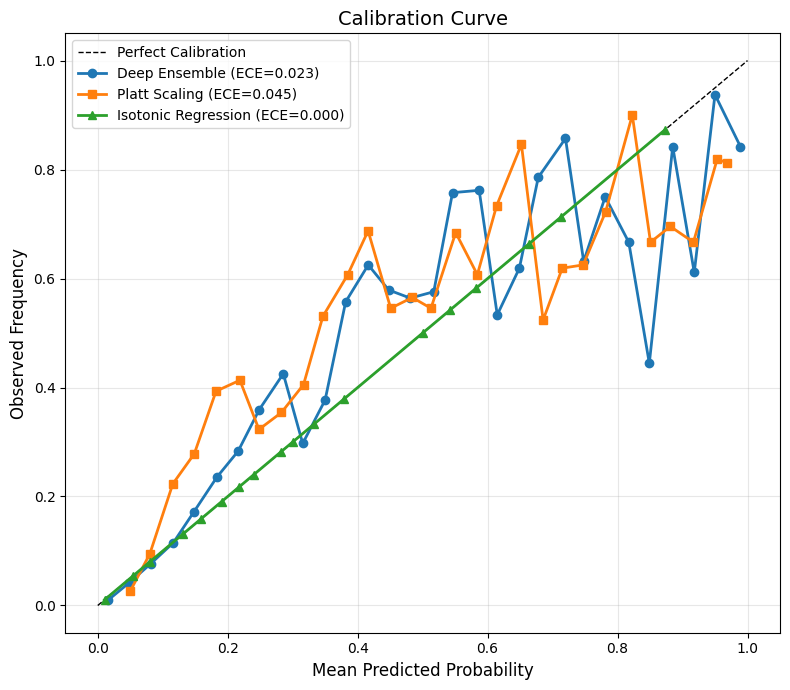

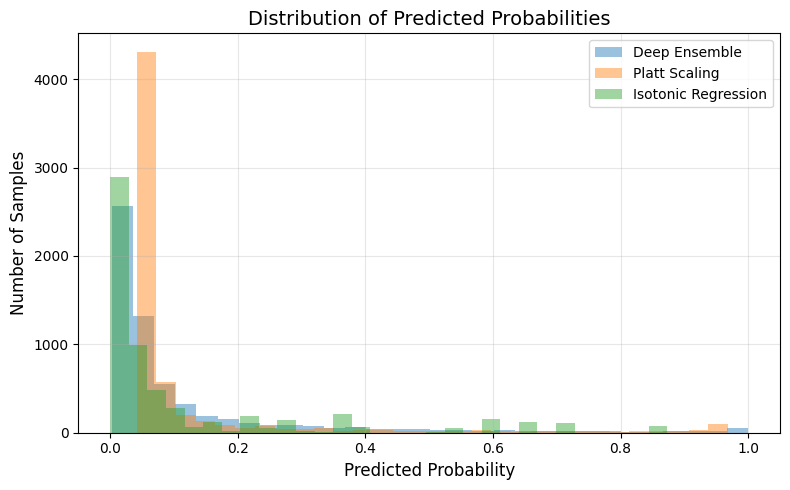

In [19]:
# ============================================================
# Calibration Comparison
# Deep Ensemble vs Platt Scaling vs Isotonic Regression
# ============================================================

%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt

from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
from sklearn.linear_model import LogisticRegression
from sklearn.isotonic import IsotonicRegression

print("="*70)
print("Calibration Comparison")
print("="*70)

# ------------------------------------------------------------------
# Validation and Test data
# (Assumes these already exist)
#
# val_prob_icu_deep_ensembles
# val_true_icu_deep_ensembles
# test_prob_icu_deep_ensembles test_prob_icu_deep_ensembles
# test_true_icu_deep_ensembles
# ------------------------------------------------------------------
val_prob_icu_deep_ensembles=test_prob_icu_deep_ensembles
val_true_icu_deep_ensembles=test_true_icu_deep_ensembles
# ============================================================
# Platt Scaling
# ============================================================
platt = LogisticRegression(max_iter=1000)

platt.fit(
    val_prob_icu_deep_ensembles.reshape(-1,1),
    val_true_icu_deep_ensembles
)

test_prob_platt = platt.predict_proba(
    test_prob_icu_deep_ensembles.reshape(-1,1)
)[:,1]

# ============================================================
# Isotonic Regression
# ============================================================
iso = IsotonicRegression(out_of_bounds="clip")

iso.fit(
    val_prob_icu_deep_ensembles,
    val_true_icu_deep_ensembles
)

test_prob_iso = iso.predict(test_prob_icu_deep_ensembles)

# ============================================================
# Expected Calibration Error
# ============================================================
def compute_ece(true_labels, pred_probs, n_bins=30):

    bins = np.linspace(0,1,n_bins+1)

    ece = 0

    total = len(pred_probs)

    for i in range(n_bins):

        mask = (
            (pred_probs >= bins[i]) &
            (pred_probs < bins[i+1])
        )

        if mask.sum() == 0:
            continue

        acc = true_labels[mask].mean()

        conf = pred_probs[mask].mean()

        ece += (mask.sum()/total)*abs(acc-conf)

    return ece

# ============================================================
# Calibration statistics
# ============================================================
def calibration_stats(y_true, probs):

    frac_pos, mean_pred = calibration_curve(
        y_true,
        probs,
        n_bins=30,
        strategy="uniform"
    )

    ece = compute_ece(y_true, probs)

    brier = brier_score_loss(y_true, probs)

    return frac_pos, mean_pred, ece, brier

# ============================================================
# Compute statistics
# ============================================================

frac_de, mean_de, ece_de, brier_de = calibration_stats(
    test_true_icu_deep_ensembles,
    test_prob_icu_deep_ensembles
)

frac_platt, mean_platt, ece_platt, brier_platt = calibration_stats(
    test_true_icu_deep_ensembles,
    test_prob_platt
)

frac_iso, mean_iso, ece_iso, brier_iso = calibration_stats(
    test_true_icu_deep_ensembles,
    test_prob_iso
)

# ============================================================
# Print Results
# ============================================================

print("\nCalibration Metrics")
print("-"*55)

print(f"Deep Ensemble")
print(f"  ECE   : {ece_de:.4f}")
print(f"  Brier : {brier_de:.4f}")

print(f"\nPlatt Scaling")
print(f"  ECE   : {ece_platt:.4f}")
print(f"  Brier : {brier_platt:.4f}")

print(f"\nIsotonic Regression")
print(f"  ECE   : {ece_iso:.4f}")
print(f"  Brier : {brier_iso:.4f}")

# ============================================================
# Plot 1 : Reliability Diagram
# ============================================================

plt.figure(figsize=(8,7))

plt.plot(
    [0,1],
    [0,1],
    '--',
    color='black',
    linewidth=1,
    label='Perfect Calibration'
)

plt.plot(
    mean_de,
    frac_de,
    marker='o',
    linewidth=2,
    label=f'Deep Ensemble (ECE={ece_de:.3f})'
)

plt.plot(
    mean_platt,
    frac_platt,
    marker='s',
    linewidth=2,
    label=f'Platt Scaling (ECE={ece_platt:.3f})'
)

plt.plot(
    mean_iso,
    frac_iso,
    marker='^',
    linewidth=2,
    label=f'Isotonic Regression (ECE={ece_iso:.3f})'
)

plt.xlabel("Mean Predicted Probability", fontsize=12)
plt.ylabel("Observed Frequency", fontsize=12)
plt.title("Calibration Curve", fontsize=14)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# Plot 2 : Probability Distribution
# ============================================================

plt.figure(figsize=(8,5))

plt.hist(
    test_prob_icu_deep_ensembles,
    bins=30,
    alpha=0.45,
    label="Deep Ensemble"
)

plt.hist(
    test_prob_platt,
    bins=30,
    alpha=0.45,
    label="Platt Scaling"
)

plt.hist(
    test_prob_iso,
    bins=30,
    alpha=0.45,
    label="Isotonic Regression"
)

plt.xlabel("Predicted Probability", fontsize=12)
plt.ylabel("Number of Samples", fontsize=12)
plt.title("Distribution of Predicted Probabilities", fontsize=14)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [29]:
# ============================================================
# Calibrated probabilities for every test sample
# ============================================================

# Original Deep Ensemble probabilities
prob_de = test_prob_icu_deep_ensembles.copy()

# Platt Scaling probabilities
prob_platt = test_prob_platt.copy()

# Isotonic Regression probabilities
prob_iso = test_prob_iso.copy()

# Store all methods together
calibrated_probabilities = {
    "Deep Ensemble": prob_de,
    "Platt Scaling": prob_platt,
    "Isotonic Regression": prob_iso
}

# Or as a matrix (rows = samples, columns = methods)
calibration_matrix = np.column_stack([
    val_true_icu_deep_ensembles,
    prob_de,
    prob_platt,
    prob_iso
])

print(calibration_matrix.shape)
print("Columns:")
print("0 = Deep Ensemble")
print("1 = Platt Scaling")
print("2 = Isotonic Regression")

(6051, 4)
Columns:
0 = Deep Ensemble
1 = Platt Scaling
2 = Isotonic Regression


In [30]:
headers = [
    "True_Label",
    "Original_Probability",
    "Platt_Scaling",
    "Isotonic_Regression"
]

Calibration_Deep_ensembles = pd.DataFrame(calibration_matrix, columns=headers)
Calibration_Deep_ensembles

,True_Label,Original_Probability,Platt_Scaling,Isotonic_Regression
0,0.0,0.127985,0.089781,0.131148
1,1.0,0.507192,0.545366,0.582278
2,0.0,0.005707,0.042213,0.004902
3,1.0,0.311372,0.248219,0.376744
4,1.0,0.023299,0.047155,0.006836
...,...,...,...,...
6046,0.0,0.058956,0.058907,0.053922
6047,0.0,0.009764,0.043307,0.005959
6048,0.0,0.024500,0.047512,0.006836
6049,0.0,0.008641,0.043001,0.005959


In [39]:
encoder = torch.load(
    "best_realmlp.pt",
    map_location="cpu",
    weights_only=False
)
encoder.eval()

BasicEncoderStaticMLP(
  (embeddings): ModuleList(
    (0): Embedding(2, 2)
    (1): Embedding(5, 5)
  )
  (layers): Sequential(
    (0): BatchNorm1d(471, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (1): Dropout(p=0.25, inplace=False)
    (2): Linear(in_features=471, out_features=128, bias=True)
    (3): ReLU(inplace=True)
    (4): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): Dropout(p=0.25, inplace=False)
    (6): Linear(in_features=128, out_features=128, bias=True)
    (7): ReLU(inplace=True)
    (8): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): Dropout(p=0.25, inplace=False)
    (10): Linear(in_features=128, out_features=128, bias=True)
    (11): ReLU(inplace=True)
    (12): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): Dropout(p=0.5, inplace=False)
    (14): Linear(in_features=128, out_features=4, bias=True)
  )
)

# MLP Calibration diagram

In [43]:
# ----------------------------------------
# Load the trained model
# ----------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


encoder = torch.load(
    "best_realmlp.pt",
    map_location=device,
    weights_only=False      # Needed in PyTorch >=2.6
)
encoder.eval()


# ----------------------------------------
# Predict on validation set
# ----------------------------------------
all_preds, all_labels = [], []

with torch.no_grad():

    for cont, cat, labels in val_loader:

        cont = cont.to(DEVICE)
        cat  = cat.to(DEVICE)

        out = encoder(static=cont, static_cat=cat)

        probs = torch.sigmoid(out["static"])

        all_preds.append(probs.cpu().numpy())
        all_labels.append(labels.numpy())

all_preds  = np.concatenate(all_preds, axis=0)
all_labels = np.concatenate(all_labels, axis=0)


# ----------------------------------------
# Extract ICU_24h predictions and labels
# ----------------------------------------
target_idx = 1

mask = ~np.isnan(all_labels[:, target_idx])

y_true = all_labels[:, target_idx]
y_prob = all_preds[:, target_idx]


# ----------------------------------------
# Save to CSV
# ----------------------------------------
results = pd.DataFrame({
    "ICU_24h_true": y_true.astype(int),
    "ICU_24h_probability": y_prob
})


print(results)


      ICU_24h_true  ICU_24h_probability
0                1             0.004015
1                0             0.014553
2                0             0.005785
3                0             0.133368
4                0             0.143087
...            ...                  ...
5819             0             0.021184
5820             0             0.254698
5821             0             0.027617
5822             1             0.026268
5823             0             0.009481

[5824 rows x 2 columns]


In [42]:
y_true

array([0., 0., 0., ..., 0., 0., 0.], shape=(5809,), dtype=float32)

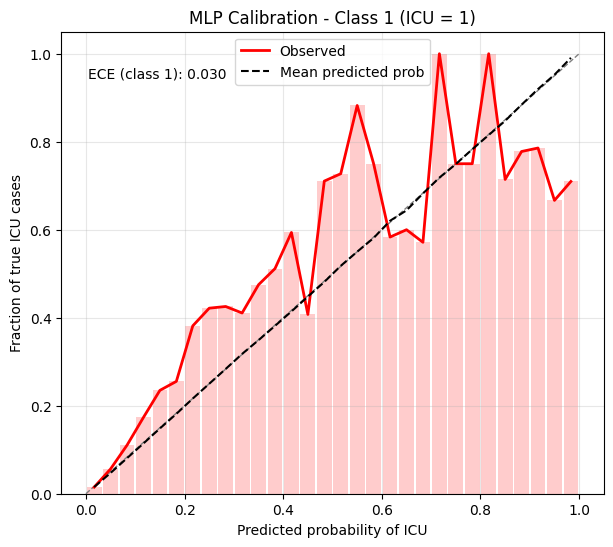

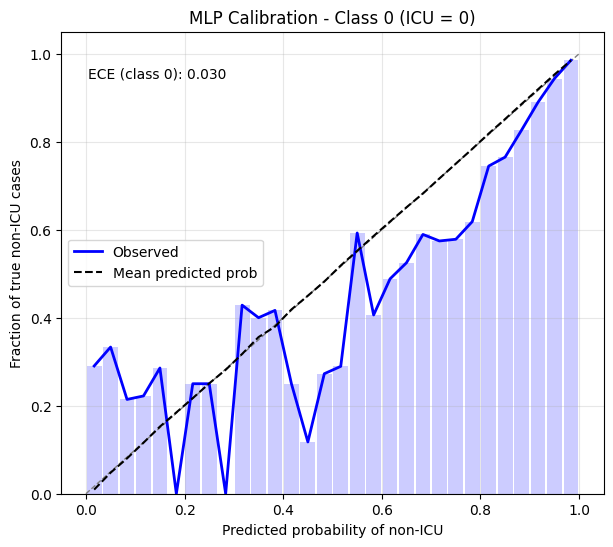

In [44]:
%matplotlib inline
import matplotlib.pyplot as plt
from IPython.display import clear_output
clear_output(wait=True)
# =========================================================
# 1. Load from results table
# =========================================================
y_true = y_true
y_prob = y_prob

mask = ~np.isnan(y_true) & ~np.isnan(y_prob)
y_true = y_true[mask]
y_prob = y_prob[mask]

# =========================================================
# 2. Binning setup
# =========================================================
n_bins = 30
bins = np.linspace(0, 1, n_bins + 1)
centers = (bins[:-1] + bins[1:]) / 2
bin_width = 1.0 / n_bins

# =========================================================
# 3. Helper function (same logic as MC dropout)
# =========================================================
def calibration_stats(y_true, y_prob):
    frac_pos = []
    conf = []
    ece = 0.0
    n = len(y_true)

    for i in range(n_bins):

        left, right = bins[i], bins[i + 1]

        if i == n_bins - 1:
            mask = (y_prob >= left) & (y_prob <= right)
        else:
            mask = (y_prob >= left) & (y_prob < right)

        size = np.sum(mask)

        if size == 0:
            frac_pos.append(np.nan)
            conf.append(np.nan)
            continue

        acc = np.mean(y_true[mask])
        avg_conf = np.mean(y_prob[mask])

        frac_pos.append(acc)
        conf.append(avg_conf)

        ece += (size / n) * abs(acc - avg_conf)

    return np.array(frac_pos), np.array(conf), ece

# =========================================================
# 4. CLASS 1 (ICU = 1)
# =========================================================
frac_pos_1_mlp, conf_1, ece_1 = calibration_stats(y_true, y_prob)

# =========================================================
# 5. CLASS 0 (ICU = 0)
# =========================================================
y_true_0 = 1 - y_true
y_prob_0 = 1 - y_prob

frac_pos_0_mlp, conf_0, ece_0 = calibration_stats(y_true_0, y_prob_0)

# =========================================================
# 6. Plot CLASS 1
# =========================================================
plt.figure(figsize=(7, 6))

plt.plot([0, 1], [0, 1], '--', color='gray', linewidth=1)

plt.bar(centers, frac_pos_1_mlp, width=bin_width * 0.9, alpha=0.2, color='red')

plt.plot(centers, frac_pos_1_mlp, color='red', linewidth=2, label="Observed")
plt.plot(centers, conf_1, color='black', linestyle='--', label="Mean predicted prob")

plt.text(0.05, 0.90, f"ECE (class 1): {ece_1:.3f}", transform=plt.gca().transAxes)

plt.xlabel("Predicted probability of ICU")
plt.ylabel("Fraction of true ICU cases")
plt.title("MLP Calibration - Class 1 (ICU = 1)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

# =========================================================
# 7. Plot CLASS 0
# =========================================================
plt.figure(figsize=(7, 6))

plt.plot([0, 1], [0, 1], '--', color='gray', linewidth=1)

plt.bar(centers, frac_pos_0_mlp, width=bin_width * 0.9, alpha=0.2, color='blue')

plt.plot(centers, frac_pos_0_mlp, color='blue', linewidth=2, label="Observed")
plt.plot(centers, conf_0, color='black', linestyle='--', label="Mean predicted prob")

plt.text(0.05, 0.90, f"ECE (class 0): {ece_0:.3f}", transform=plt.gca().transAxes)

plt.xlabel("Predicted probability of non-ICU")
plt.ylabel("Fraction of true non-ICU cases")
plt.title("MLP Calibration - Class 0 (ICU = 0)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [ ]:
# ============================================================
# MLP Calibration Methods + Calibration Matrix
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.isotonic import IsotonicRegression
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# Remove NaNs
# ------------------------------------------------------------
mask_test = ~np.isnan(y_true) & ~np.isnan(y_prob)

mlp_true = y_true[mask_test].astype(int)
mlp_prob = y_prob[mask_test]

val_y_prob=mlp_prob
val_y_true=mlp_true
# ============================================================
# 1. Platt Scaling
# ============================================================

platt_mlp = LogisticRegression(max_iter=1000)

platt_mlp.fit(
    val_y_prob.reshape(-1, 1),
    val_y_true.astype(int)
)

prob_platt_mlp = platt_mlp.predict_proba(
    mlp_prob.reshape(-1, 1)
)[:, 1]


# ============================================================
# 2. Isotonic Regression
# ============================================================

iso_mlp = IsotonicRegression(out_of_bounds="clip")

iso_mlp.fit(
    val_y_prob,
    val_y_true.astype(int)
)

prob_iso_mlp = iso_mlp.predict(
    mlp_prob
)


# ============================================================
# 3. Store Calibration Matrix
# ============================================================

mlp_calibration_matrix = np.column_stack([
    mlp_true,
    mlp_prob,
    prob_platt_mlp,
    prob_iso_mlp
])


mlp_headers = [
    "True_Label",
    "MLP_Original_Probability",
    "MLP_Platt_Scaling",
    "MLP_Isotonic_Regression"
]


# Convert to DataFrame
mlp_calibration_df = pd.DataFrame(
    mlp_calibration_matrix,
    columns=mlp_headers
)


print("MLP Calibration Matrix Shape:")
print(mlp_calibration_matrix.shape)

print("\nFirst samples:")
print(mlp_calibration_df.head())


# Optional save


MLP Calibration Matrix Shape:
(5807, 4)

First samples:
   True_Label  MLP_Original_Probability  MLP_Platt_Scaling  \
0         1.0                  0.004015           0.049338   
1         0.0                  0.014553           0.052486   
2         0.0                  0.005785           0.049854   
3         0.0                  0.133368           0.103540   
4         0.0                  0.143087           0.109254   

   MLP_Isotonic_Regression  
0                 0.001792  
1                 0.014826  
2                 0.001792  
3                 0.219101  
4                 0.219101  


# MC Dropout

In [48]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss
)
def mc_dropout_predict(model, test_loader, device, n_samples=50):

    model.train()  # IMPORTANT: keep dropout active

    all_mean_preds = []
    all_uncertainties = []
    all_labels = []

    with torch.no_grad():

        for cont, cat, labels in test_loader:

            cont = cont.to(device)
            cat  = cat.to(device)

            mc_samples = []

            # ----------------------------------------
            # Multiple stochastic forward passes
            # ----------------------------------------
            for _ in range(n_samples):

                out = model(static=cont, static_cat=cat)
                probs = torch.sigmoid(out["static"])

                mc_samples.append(probs.cpu().numpy())

            mc_samples = np.array(mc_samples)

            # -------------
            # 
            # ---------------------------
            # MC statistics
            # ----------------------------------------
            mean_preds = mc_samples.mean(axis=0)
            uncertainty = mc_samples.std(axis=0)

            all_mean_preds.append(mean_preds)
            all_uncertainties.append(uncertainty)
            all_labels.append(labels.numpy())

    all_mean_preds = np.concatenate(all_mean_preds, axis=0)
    all_uncertainties = np.concatenate(all_uncertainties, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)

    return all_mean_preds, all_uncertainties, all_labels


Running Monte Carlo Dropout...


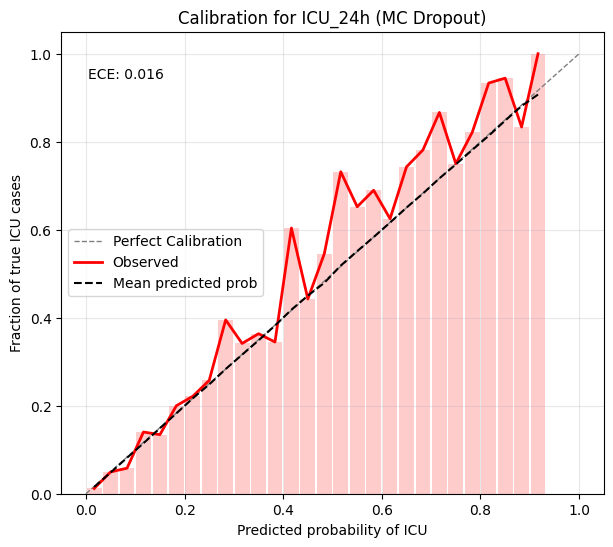

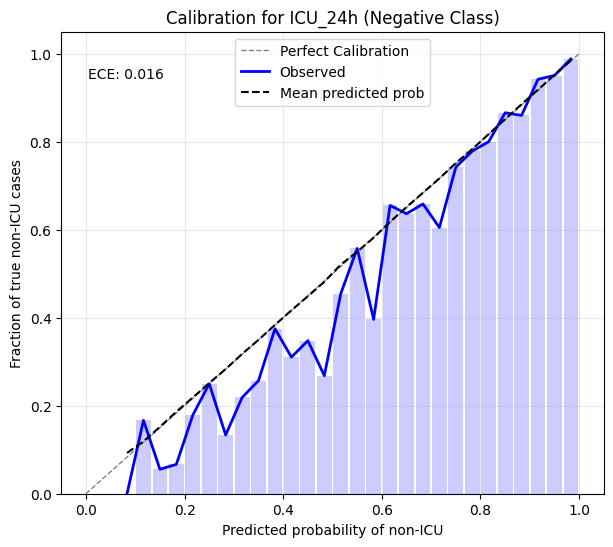

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# 1. MC Dropout prediction
# =========================================================
print("\nRunning Monte Carlo Dropout...")

all_mean_preds, all_uncertainties, y_true = mc_dropout_predict(
    encoder,
    test_loader,
    device,
    n_samples=50
)

# =========================================================
# 2. Extract ICU_24h only
# =========================================================
target_idx = 1

y_prob = all_mean_preds[:, target_idx]
y_true = y_true[:, target_idx]

mask = ~np.isnan(y_true)

y_prob_mc = y_prob[mask]
y_true_mc = y_true[mask].astype(int)

# =========================================================
# 3. Manual binning (same style as your plot)
# =========================================================
n_bins = 30
bins = np.linspace(0, 1, n_bins + 1)

frac_pos_mc = []
conf = []
bin_sizes = []

ece = 0.0
n = len(y_true_mc)

for i in range(n_bins):

    left, right = bins[i], bins[i + 1]

    if i == n_bins - 1:
        bin_mask = (y_prob_mc >= left) & (y_prob_mc <= right)
    else:
        bin_mask = (y_prob_mc >= left) & (y_prob_mc < right)

    size = np.sum(bin_mask)

    if size == 0:
        frac_pos_mc.append(np.nan)
        conf.append(np.nan)
        bin_sizes.append(0)
        continue

    acc = np.mean(y_true_mc[bin_mask])
    avg_conf = np.mean(y_prob_mc[bin_mask])

    frac_pos_mc.append(acc)
    conf.append(avg_conf)
    bin_sizes.append(size)

    ece += (size / n) * abs(acc - avg_conf)

frac_pos_mc = np.array(frac_pos_mc)
conf = np.array(conf)

centers = (bins[:-1] + bins[1:]) / 2
bin_width = 1.0 / n_bins

# =========================================================
# 4. Plot (SAME STYLE AS YOUR ORIGINAL)
# =========================================================
plt.figure(figsize=(7, 6))

plt.plot([0, 1], [0, 1], '--', color='gray', linewidth=1, label="Perfect Calibration")

# observed fraction (bars)
plt.bar(centers, frac_pos_mc, width=bin_width * 0.9, alpha=0.2, color='red')

# observed curve
plt.plot(centers, frac_pos_mc, color='red', linewidth=2, label="Observed")

# mean predicted probability curve
plt.plot(centers, conf, color='black', linestyle='--', label="Mean predicted prob")

plt.text(0.05, 0.90, f"ECE: {ece:.3f}", transform=plt.gca().transAxes)

plt.xlabel("Predicted probability of ICU")
plt.ylabel("Fraction of true ICU cases")
plt.title("Calibration for ICU_24h (MC Dropout)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

# =========================================================
# 5. SAME FOR NEGATIVE CLASS (ICU = 0)
# =========================================================
y_prob_neg_mc = 1 - y_prob_mc
y_true_neg_mc = 1 - y_true_mc

frac_n_mc = []
conf_n = []

ece_neg = 0.0

for i in range(n_bins):

    left, right = bins[i], bins[i + 1]

    if i == n_bins - 1:
        bin_mask = (y_prob_neg_mc >= left) & (y_prob_neg_mc <= right)
    else:
        bin_mask = (y_prob_neg_mc >= left) & (y_prob_neg_mc < right)

    size = np.sum(bin_mask)

    if size == 0:
        frac_n_mc.append(np.nan)
        conf_n.append(np.nan)
        continue

    acc = np.mean(y_true_neg_mc[bin_mask])
    avg_conf = np.mean(y_prob_neg_mc[bin_mask])

    frac_n_mc.append(acc)
    conf_n.append(avg_conf)

    ece_neg += (size / n) * abs(acc - avg_conf)

frac_n_mc = np.array(frac_n_mc)
conf_n = np.array(conf_n)

# =========================================================
# 6. Plot negative class (same style, NO "0 marker")
# =========================================================
plt.figure(figsize=(7, 6))

plt.plot([0, 1], [0, 1], '--', color='gray', linewidth=1, label="Perfect Calibration")

plt.bar(centers, frac_n_mc, width=bin_width * 0.9, alpha=0.2, color='blue')

plt.plot(centers, frac_n_mc, color='blue', linewidth=2, label="Observed")
plt.plot(centers, conf_n, color='black', linestyle='--', label="Mean predicted prob")

plt.text(0.05, 0.90, f"ECE: {ece_neg:.3f}", transform=plt.gca().transAxes)

plt.xlabel("Predicted probability of non-ICU")
plt.ylabel("Fraction of true non-ICU cases")
plt.title("Calibration for ICU_24h (Negative Class)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [51]:
# ============================================================
# MC Dropout Calibration Methods + Calibration Matrix
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.isotonic import IsotonicRegression
import pandas as pd
import numpy as np


# ============================================================
# 1. Original MC Dropout probabilities
# ============================================================

prob_mc = y_prob_mc.copy()
true_mc = y_true_mc.copy()
val_y_prob_mc=prob_mc
val_y_true_mc=true_mc
# ============================================================
# 2. Platt Scaling
# ============================================================

platt_mc = LogisticRegression(max_iter=1000)

platt_mc.fit(
    val_y_prob_mc.reshape(-1, 1),
    val_y_true_mc.astype(int)
)

prob_platt_mc = platt_mc.predict_proba(
    prob_mc.reshape(-1, 1)
)[:, 1]


# ============================================================
# 3. Isotonic Regression
# ============================================================

iso_mc = IsotonicRegression(out_of_bounds="clip")

iso_mc.fit(
    val_y_prob_mc,
    val_y_true_mc.astype(int)
)

prob_iso_mc = iso_mc.predict(
    prob_mc
)


# ============================================================
# 4. Store calibration matrix
# ============================================================

mc_calibration_matrix = np.column_stack([
    true_mc,
    prob_mc,
    prob_platt_mc,
    prob_iso_mc
])


mc_headers = [
    "True_Label",
    "MC_Dropout_Probability",
    "MC_Dropout_Platt_Scaling",
    "MC_Dropout_Isotonic_Regression"
]


# DataFrame format
mc_calibration_df = pd.DataFrame(
    mc_calibration_matrix,
    columns=mc_headers
)


print("MC Dropout Calibration Matrix Shape:")
print(mc_calibration_matrix.shape)

print("\nFirst samples:")
print(mc_calibration_df.head())


# Optional save
# mc_calibration_df.to_csv(
#     "MC_dropout_calibration_matrix.csv",
#     index=False
# )

MC Dropout Calibration Matrix Shape:
(6051, 4)

First samples:
   True_Label  MC_Dropout_Probability  MC_Dropout_Platt_Scaling  \
0         0.0                0.097279                  0.068422   
1         1.0                0.651695                  0.813498   
2         0.0                0.009302                  0.036995   
3         1.0                0.368340                  0.351051   
4         1.0                0.044138                  0.047306   

   MC_Dropout_Isotonic_Regression  
0                        0.081301  
1                        0.720000  
2                        0.006849  
3                        0.353659  
4                        0.051163  


# Combine all the methods

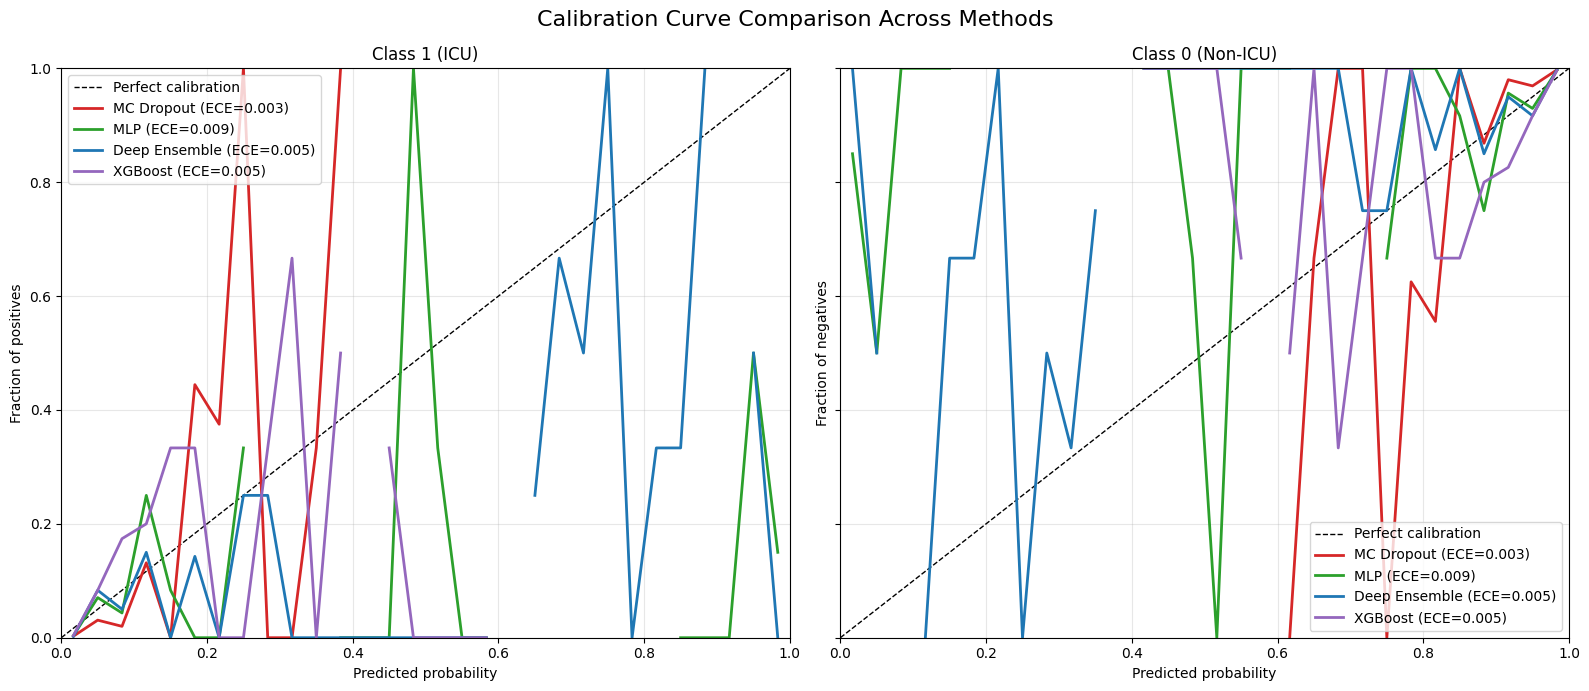

In [65]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharex=True, sharey=True)

colors = {
    "MC Dropout": "#d62728",
    "MLP": "#2ca02c",
    "Deep Ensemble": "#1f77b4",
    "XGBoost": "#9467bd"
}

# ==========================================================
# Class 1 (ICU)
# ==========================================================
ax = axes[0]

ax.plot([0, 1], [0, 1], '--', color='black', linewidth=1,
        label='Perfect calibration')

ax.plot(
    centers,
    frac_pos_mc,
    color=colors["MC Dropout"],
    linewidth=2,
    label=f"MC Dropout (ECE={ece:.3f})"
)

ax.plot(
    centers,
    frac_pos_1_mlp,
    color=colors["MLP"],
    linewidth=2,
    label=f"MLP (ECE={ece_1:.3f})"
)

ax.plot(
    centers,
    frac_pos_DE,
    color=colors["Deep Ensemble"],
    linewidth=2,
    label=f"Deep Ensemble (ECE={ece_pos_DE:.3f})"
)

ax.plot(
    xgb_centers_1,
    xgb_frac_1,
    color=colors["XGBoost"],
    linewidth=2,
    label=f"XGBoost (ECE={xgb_ece_pos:.3f})"
)

ax.set_xlim(0,1)
ax.set_ylim(0,1)
ax.set_xlabel("Predicted probability")
ax.set_ylabel("Fraction of positives")
ax.set_title("Class 1 (ICU)")
ax.grid(alpha=0.3)
ax.legend()


# ==========================================================
# Class 0 (Non-ICU)
# ==========================================================
ax = axes[1]

ax.plot([0, 1], [0, 1], '--', color='black', linewidth=1,
        label='Perfect calibration')

ax.plot(
    centers,
    frac_n_mc,
    color=colors["MC Dropout"],
    linewidth=2,
    label=f"MC Dropout (ECE={ece_neg:.3f})"
)

ax.plot(
    centers,
    frac_pos_0_mlp,
    color=colors["MLP"],
    linewidth=2,
    label=f"MLP (ECE={ece_0:.3f})"
)

ax.plot(
    centers,
    frac_neg_DE,
    color=colors["Deep Ensemble"],
    linewidth=2,
    label=f"Deep Ensemble (ECE={ece_neg_DE:.3f})"
)

ax.plot(
    xgb_centers_0,
    xgb_frac_0,
    color=colors["XGBoost"],
    linewidth=2,
    label=f"XGBoost (ECE={xgb_ece_neg:.3f})"
)

ax.set_xlim(0,1)
ax.set_ylim(0,1)
ax.set_xlabel("Predicted probability")
ax.set_ylabel("Fraction of negatives")
ax.set_title("Class 0 (Non-ICU)")
ax.grid(alpha=0.3)
ax.legend()

plt.suptitle("Calibration Curve Comparison Across Methods", fontsize=16)
plt.tight_layout()
plt.show()

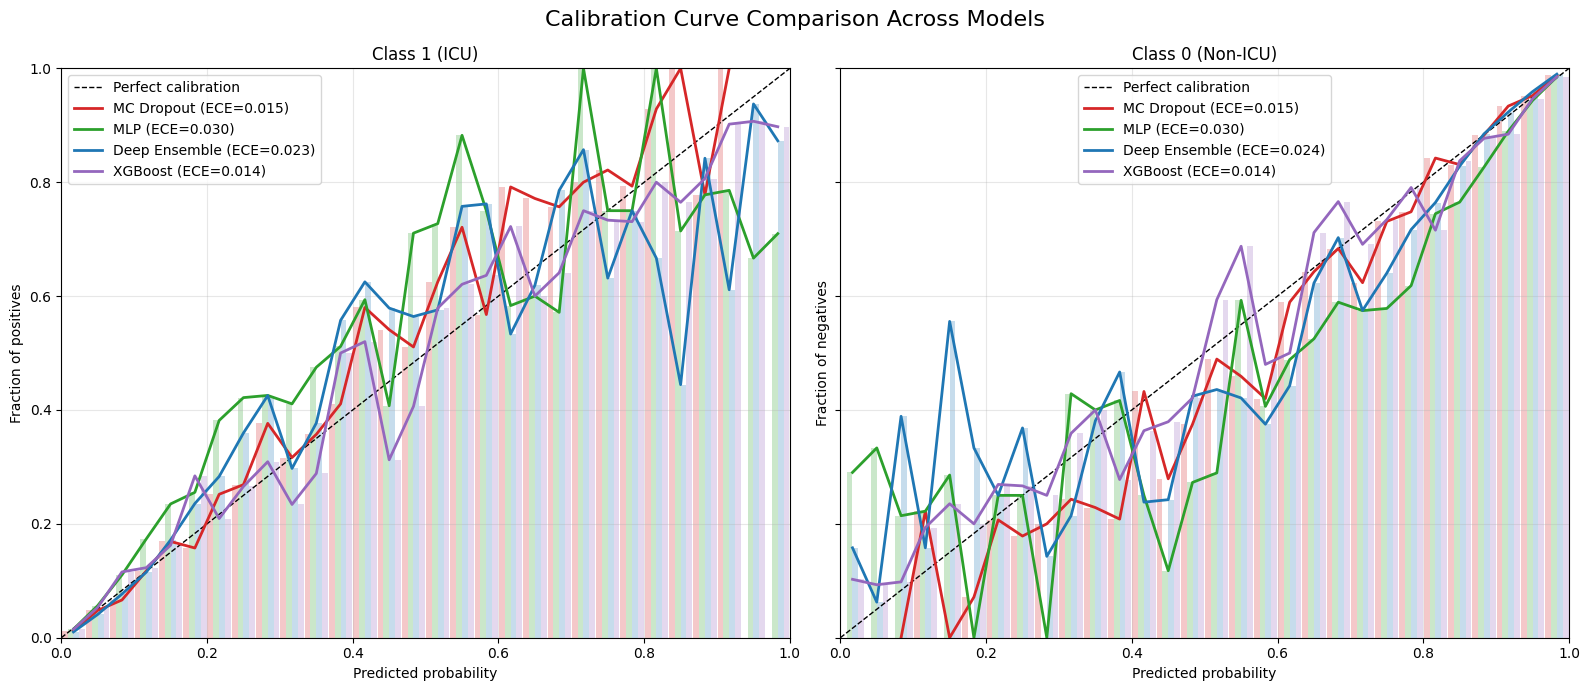

In [37]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharex=True, sharey=True)

colors = {
    "MC Dropout": "#d62728",
    "MLP": "#2ca02c",
    "Deep Ensemble": "#1f77b4",
    "XGBoost": "#9467bd"
}

# Width and offsets for grouped bars
bar_width = 0.008
offsets = np.array([-1.5, -0.5, 0.5, 1.5]) * bar_width

# ==========================================================
# Class 1 (ICU)
# ==========================================================
ax = axes[0]

ax.plot([0, 1], [0, 1], '--', color='black', linewidth=1,
        label='Perfect calibration')

# ----------------------------
# Bars
# ----------------------------
ax.bar(centers + offsets[0], frac_pos_mc,
       width=bar_width, color=colors["MC Dropout"], alpha=0.25)

ax.bar(centers + offsets[1], frac_pos_1_mlp,
       width=bar_width, color=colors["MLP"], alpha=0.25)

ax.bar(centers + offsets[2], frac_pos_DE,
       width=bar_width, color=colors["Deep Ensemble"], alpha=0.25)

ax.bar(xgb_centers_1 + offsets[3], xgb_frac_1,
       width=bar_width, color=colors["XGBoost"], alpha=0.25)

# ----------------------------
# Curves
# ----------------------------
ax.plot(
    centers,
    frac_pos_mc,
    color=colors["MC Dropout"],
    linewidth=2,
    label=f"MC Dropout (ECE={ece:.3f})"
)

ax.plot(
    centers,
    frac_pos_1_mlp,
    color=colors["MLP"],
    linewidth=2,
    label=f"MLP (ECE={ece_1:.3f})"
)

ax.plot(
    centers,
    frac_pos_DE,
    color=colors["Deep Ensemble"],
    linewidth=2,
    label=f"Deep Ensemble (ECE={ece_pos_DE:.3f})"
)

ax.plot(
    xgb_centers_1,
    xgb_frac_1,
    color=colors["XGBoost"],
    linewidth=2,
    label=f"XGBoost (ECE={xgb_ece_pos:.3f})"
)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel("Predicted probability")
ax.set_ylabel("Fraction of positives")
ax.set_title("Class 1 (ICU)")
ax.grid(alpha=0.3)
ax.legend()

# ==========================================================
# Class 0 (Non-ICU)
# ==========================================================
ax = axes[1]

ax.plot([0, 1], [0, 1], '--', color='black', linewidth=1,
        label='Perfect calibration')

# ----------------------------
# Bars
# ----------------------------
ax.bar(centers + offsets[0], frac_n_mc,
       width=bar_width, color=colors["MC Dropout"], alpha=0.25)

ax.bar(centers + offsets[1], frac_pos_0_mlp,
       width=bar_width, color=colors["MLP"], alpha=0.25)

ax.bar(centers + offsets[2], frac_neg_DE,
       width=bar_width, color=colors["Deep Ensemble"], alpha=0.25)

ax.bar(xgb_centers_0 + offsets[3], xgb_frac_0,
       width=bar_width, color=colors["XGBoost"], alpha=0.25)

# ----------------------------
# Curves
# ----------------------------
ax.plot(
    centers,
    frac_n_mc,
    color=colors["MC Dropout"],
    linewidth=2,
    label=f"MC Dropout (ECE={ece_neg:.3f})"
)

ax.plot(
    centers,
    frac_pos_0_mlp,
    color=colors["MLP"],
    linewidth=2,
    label=f"MLP (ECE={ece_0:.3f})"
)

ax.plot(
    centers,
    frac_neg_DE,
    color=colors["Deep Ensemble"],
    linewidth=2,
    label=f"Deep Ensemble (ECE={ece_neg_DE:.3f})"
)

ax.plot(
    xgb_centers_0,
    xgb_frac_0,
    color=colors["XGBoost"],
    linewidth=2,
    label=f"XGBoost (ECE={xgb_ece_neg:.3f})"
)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel("Predicted probability")
ax.set_ylabel("Fraction of negatives")
ax.set_title("Class 0 (Non-ICU)")
ax.grid(alpha=0.3)
ax.legend()

plt.suptitle("Calibration Curve Comparison Across Models", fontsize=16)
plt.tight_layout()
plt.show()

In [53]:
mlp_calibration_df.to_csv(
     "MLP_calibration_matrix.csv",
     index=False
 )
mc_calibration_df.to_csv(
    "MC_dropout_calibration_matrix.csv",
    index=False
)
Calibration_Deep_ensembles.to_csv(
    "Deep_ensembles_calibration_matrix.csv",
    index=False
)
calibration_XGB.to_csv(
    "xgb_calibration_matrix.csv",
    index=False
)